In [1]:
!pip install wordcloud -q
!pip install tqdm -q
!pip install transformers -q
!pip install torch -q

#=====================Importing Libraries======================

import pandas as pd
import numpy as np
import re
import pickle
import torch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, f1_score
from sklearn.decomposition import PCA
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from wordcloud import WordCloud
from tqdm.notebook import tqdm

#======================Import BERT components===================

from transformers import AutoTokenizer, AutoModel

In [2]:
#================Downloading NLTK Resources===============

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
#===============Loading dataset=====================

df = pd.read_csv('/content/Recipe Reviews and user feedback dataset UCI.csv')
print("columns available in the dataset:",df.columns)
df.head()

columns available in the dataset: Index(['Unnamed: 0', 'recipe_number', 'recipe_code', 'recipe_name',
       'comment_id', 'user_id', 'user_name', 'user_reputation', 'created_at',
       'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score',
       'text', 'sentiment', 'sentiment_confidence'],
      dtype='object')


,Unnamed: 0,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text,sentiment,sentiment_confidence
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ...",positive,0.848168
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...,positive,0.760440
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...,positive,0.918948
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee...",neutral,0.695893
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...,positive,0.985044


In [4]:
df = df.drop(columns =['Unamed:0'],errors = 'ignore')

In [5]:
#====================Text Cleaning========================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)


In [6]:
#================Checking all available columns================

print("columns available after preprocessing:")
print(df.columns)

columns available after preprocessing:
Index(['Unnamed: 0', 'recipe_number', 'recipe_code', 'recipe_name',
       'comment_id', 'user_id', 'user_name', 'user_reputation', 'created_at',
       'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score',
       'text', 'sentiment', 'sentiment_confidence'],
      dtype='object')


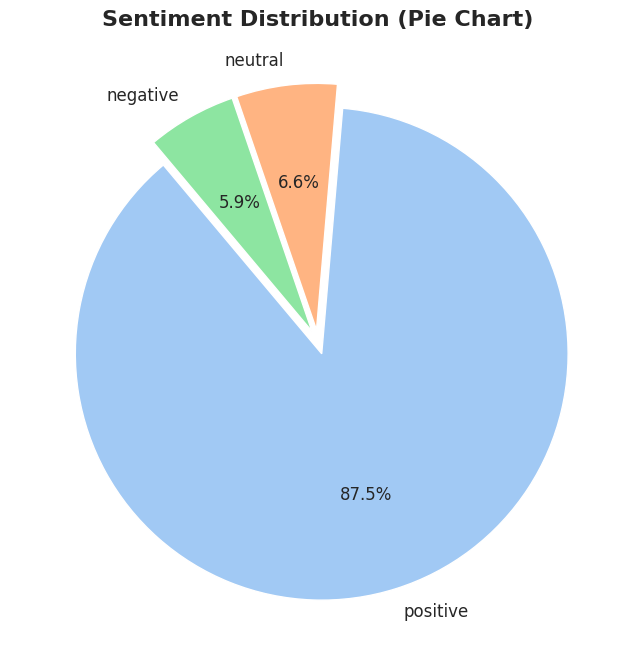

In [7]:
# =====================CHART - 1===========================
# ================== SENTIMENT DISTRIBUTION (PIE CHART) ================


#=========Count of no: of reviews per sentiment===========
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct = '%1.1f%%',
    startangle=130,
    colors=sns.color_palette("pastel"),
    explode = [0.05]*len(sentiment_counts),
    textprops = {'fontsize':12}
)
plt.title("Sentiment Distribution (Pie Chart)",fontsize=16,fontweight='bold')
plt.show()

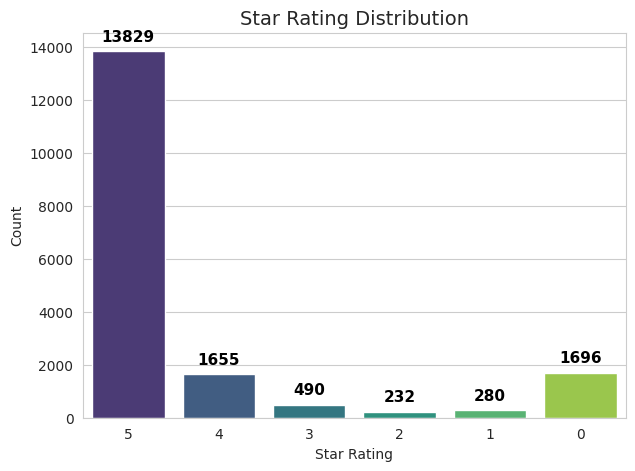

In [8]:
# ===================== Chart - 2 ========================
# ==================== Rating Stars ================================

plt.figure(figsize=(7,5))

rating_col = "stars"

# =============== Sort by star values descending
order = sorted(df[rating_col].unique(), reverse=True)

ax = sns.countplot(x=rating_col, data=df, order=order, palette="viridis")
plt.title("Star Rating Distribution", fontsize=14)

# Add values above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        str(int(height)),
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
        textcoords='offset points'
    )

plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

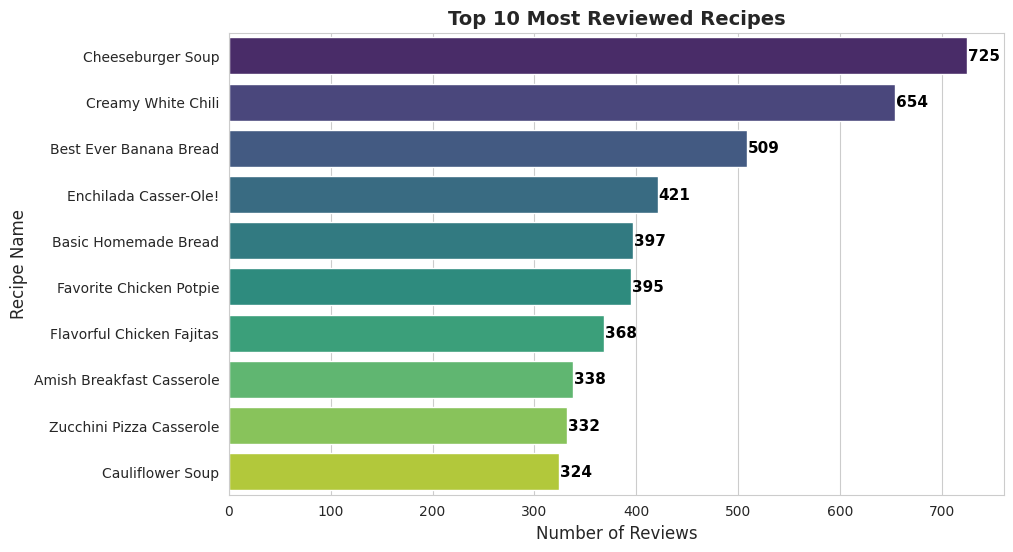

In [9]:
# ==================  Chart 3   =================================
# =========== Top 10 Most Reviewed Recipes ===============================================================

plt.figure(figsize=(10,6))

top_recipes = df['recipe_name'].value_counts().head(10)

ax = sns.barplot(
    x=top_recipes.values,
    y=top_recipes.index,
    palette='viridis'
)

plt.title("Top 10 Most Reviewed Recipes", fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Recipe Name", fontsize=12)


for i, v in enumerate(top_recipes.values):
    ax.text(
        v + 1,
        i,
        str(v),
        color='black',
        fontweight='bold',
        va='center',
        fontsize=11
    )


plt.show()


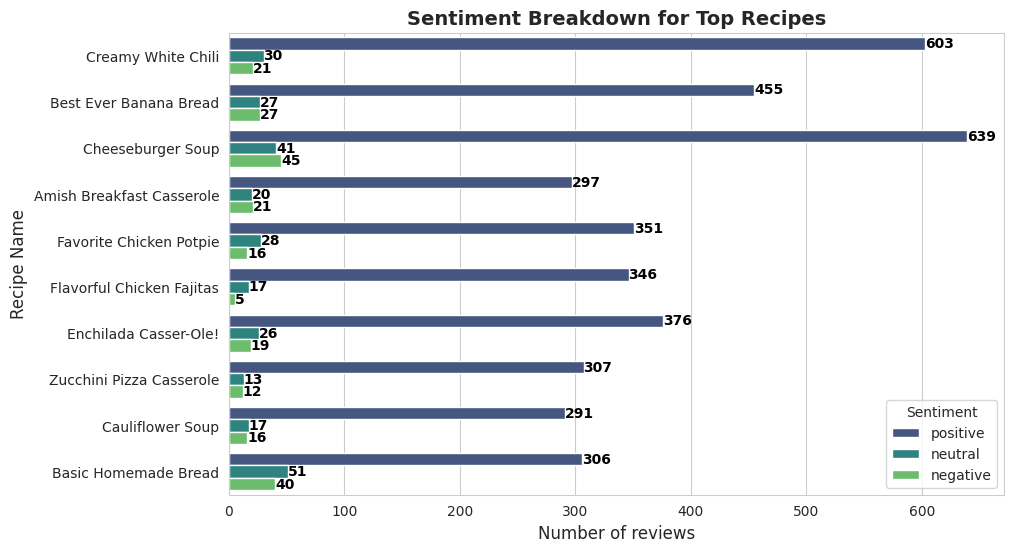

In [10]:
# ===================Chart 4====================
# ===============Sentiment Breakdown for Top Recipes==============


plt.figure(figsize=(10,6))

ax = sns.countplot(
    y='recipe_name',
    hue='sentiment',
    data=df[df['recipe_name'].isin(top_recipes.index)],
    palette='viridis',
)

plt.title("Sentiment Breakdown for Top Recipes", fontsize=14, fontweight="bold")
plt.xlabel("Number of reviews", fontsize=12)
plt.ylabel("Recipe Name", fontsize=12)

plt.legend(title='Sentiment')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        label_type='edge',
        fontsize=10,fontweight='bold',color='black')

plt.show()

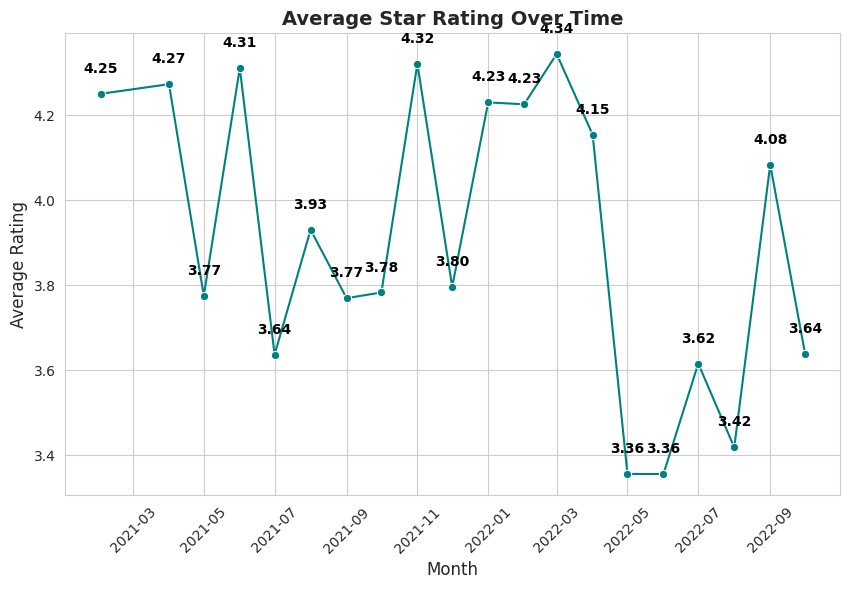

In [11]:
# ================== Chart - 5 =============================
#===============Average Star Ratings Over Time====================

# Ensure 'stars' is numeric
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')

# Convert the 'created_at' column to datetime format
df['created_at'] = pd.to_datetime(df['created_at'], unit='s', errors='coerce')

# Create a 'month' column to group data by month
df['month'] = df['created_at'].dt.to_period('M').dt.to_timestamp()

# Drop rows with missing 'stars' or 'month' values
df = df.dropna(subset=['stars', 'month'])

# Compute average rating per month
monthly_avg = df.groupby('month')['stars'].mean().reset_index()


plt.figure(figsize=(10,6))
ax = sns.lineplot(
    x='month',
    y='stars',
    data=monthly_avg,
    marker='o',
    color='teal'
)

plt.title("Average Star Rating Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=45)

for i, row in monthly_avg.iterrows():
    ax.text(
        row['month'],
        row['stars'] + 0.05,
        f"{row['stars']:.2f}",
        color='black', fontsize=10, ha='center', fontweight='bold'
    )

plt.show()

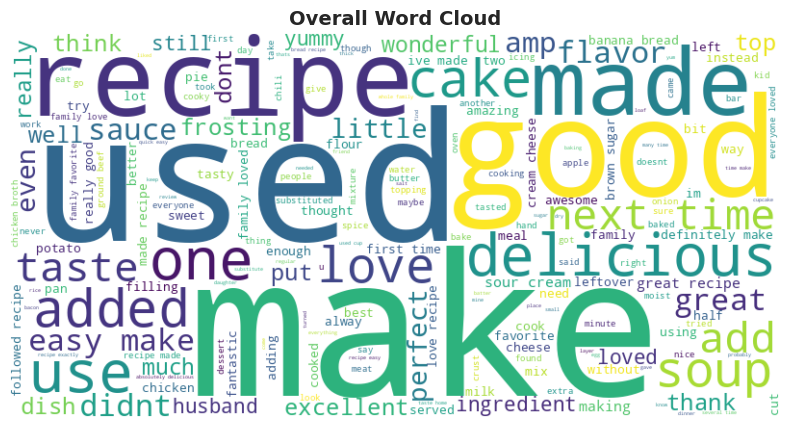

In [12]:
#========================= Overall world cloud ==================

df['clean_text'] = df['text'].apply(clean_text)
# Combine all cleaned text
all_words = df['clean_text'].str.cat(sep=" ")

# ========Creating and displaying the overall worldcloud===========
wc = WordCloud(width = 800, height = 400, background_color = 'white',colormap='viridis').generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation = 'bilinear')
plt.axis("off")
plt.title("Overall Word Cloud", fontsize=14, fontweight='bold')
plt.show()

Model Training with Bert

In [13]:
TARGET_COL = "sentiment"
BERT_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
#=============Loading tokenizer and transformer model===============

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model = bert_model.to(device)
bert_model.eval()

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dr

In [16]:
# =========== Cleaning Text for model training =================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s!?]", "", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [17]:
# ================ Extra Numeric Features =======================

df["text_length"] = df["clean_text"].str.len()
df["word_count"] = df["clean_text"].str.split().apply(len)
df["exclamation_count"] = df["clean_text"].str.count("!")
df["question_count"] = df["clean_text"].str.count("\?")

positive_words = [
    "good", "great", "love", "best", "excellent", "amazing", "nice", "perfect",
    "tasty", "delicious", "awesome", "fantastic", "wonderful", "superb"
]

neutral_words = [
    "average", "okay", "fine", "decent", "normal", "moderate", "fair",
    "plain", "simple", "acceptable", "standard", "usual","nothing special",
    "ordinary", "not bad", "not great", "balanced", "neutral","expected",
    "alright", "basic","but","however"
]

negative_words = [
    "bad", "worst", "hate", "terrible", "poor", "awful", "stale", "bland",
    "disgusting", "overcooked", "undercooked", "boring", "dry", "oily"
]

df["positive_words"] = df["clean_text"].apply(
    lambda x: sum(1 for word in positive_words if word in x)
)
df["negative_words"] = df["clean_text"].apply(
    lambda x: sum(1 for word in negative_words if word in x)
)

simple_features = [
    "text_length", "word_count", "exclamation_count",
    "question_count", "positive_words", "negative_words"
]

In [18]:
# ================= Creating Bert Embeddings =====================

def get_bert_embedding(text, max_length=128):
  inputs = tokenizer(
      text, return_tensors="pt",
      truncation=True,
      padding="max_length",
      max_length=max_length)
  inputs = {key: value.to(device) for key, value in inputs.items()}
  with torch.no_grad():
    outputs = bert_model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
  return cls_embedding.flatten()

  #============= Creating Embeddings for the whole dataset============

bert_embeddings = []
batch_size = 32

for i in tqdm(range(0, len(df), batch_size)):
  batch = df["clean_text"][i : i + batch_size].tolist()
  for text in batch:
    embedding = get_bert_embedding(text)
    bert_embeddings.append(embedding)

bert_embeddings_array = np.array(bert_embeddings)

pca = PCA(n_components=100, random_state = 42)
bert_embeddings_reduced = pca.fit_transform(bert_embeddings)

simple_feature_values = df[simple_features].fillna(0).values

X = np.hstack([bert_embeddings_reduced, simple_feature_values])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y)


  0%|          | 0/569 [00:00<?, ?it/s]

In [19]:
# ================= Training Logistic Regression and Support Vector Classifier========================

logistic_regression_model = LogisticRegression(max_iter=1000, C=1.0,
                          class_weight='balanced',
                          random_state=42)
logistic_regression_model.fit(X_train, y_train)
logistic_regression__pred = logistic_regression_model.predict(X_test)


svm_model = LinearSVC(max_iter=1000, C=1.0,
    class_weight='balanced',
    random_state=42,
)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

In [20]:
train_pred = logistic_regression_model.predict(X_train)
test_pred = logistic_regression_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Overfit Gap:", train_acc - test_acc)

Train Accuracy: 0.9678239944998281
Test Accuracy: 0.956832554302997
Overfit Gap: 0.010991440196831181


In [21]:
train_pred = svm_model.predict(X_train)
test_pred = svm_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Overfit Gap:", train_acc - test_acc)

Train Accuracy: 0.9749742179443107
Test Accuracy: 0.9656310145724498
Overfit Gap: 0.009343203371860898


Logistic Regression Confusion Matrix:
[[ 190   20    3]
 [   8  222   10]
 [  28   88 3068]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.89      0.87       213
     neutral       0.67      0.93      0.78       240
    positive       1.00      0.96      0.98      3184

    accuracy                           0.96      3637
   macro avg       0.84      0.93      0.87      3637
weighted avg       0.97      0.96      0.96      3637

Linear SVC Confusion Matrix:
[[ 182   26    5]
 [   9  215   16]
 [  19   50 3115]]
Linear SVC Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86       213
     neutral       0.74      0.90      0.81       240
    positive       0.99      0.98      0.99      3184

    accuracy                           0.97      3637
   macro avg       0.87      0.91      0.89      3637
weighted avg       0.97      0.97      

Text(627.9949494949494, 0.5, 'True Labels')

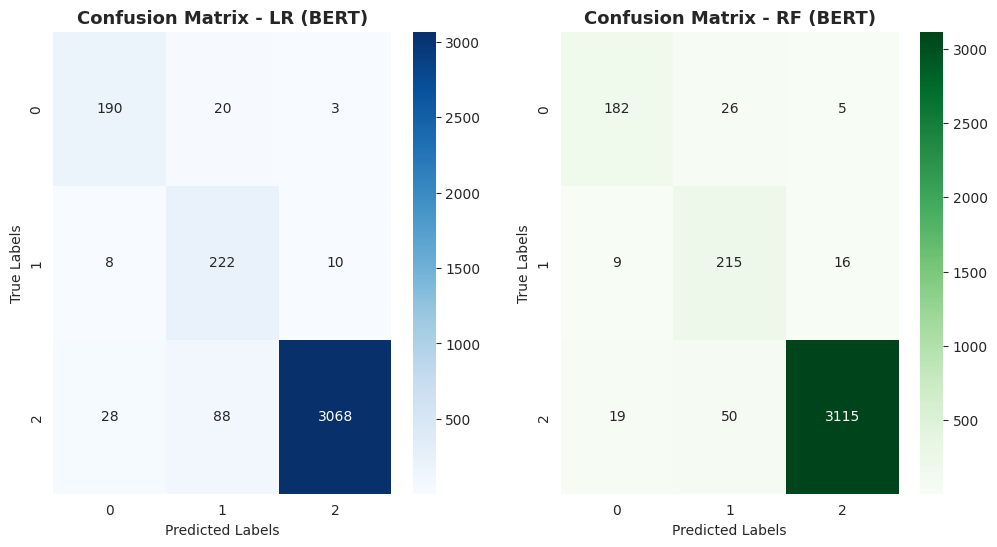

In [22]:
#============== Confusion Matrix and Classification Report===================

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, logistic_regression__pred))
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_regression__pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cm_lr = confusion_matrix(y_test, logistic_regression__pred, labels=logistic_regression_model.classes_)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix - LR (BERT)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

print("Linear SVC Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("Linear SVC Classification Report:")
print(classification_report(y_test, svm_pred))
cm_rf = confusion_matrix(y_test, svm_pred, labels=svm_model.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Confusion Matrix - RF (BERT)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")

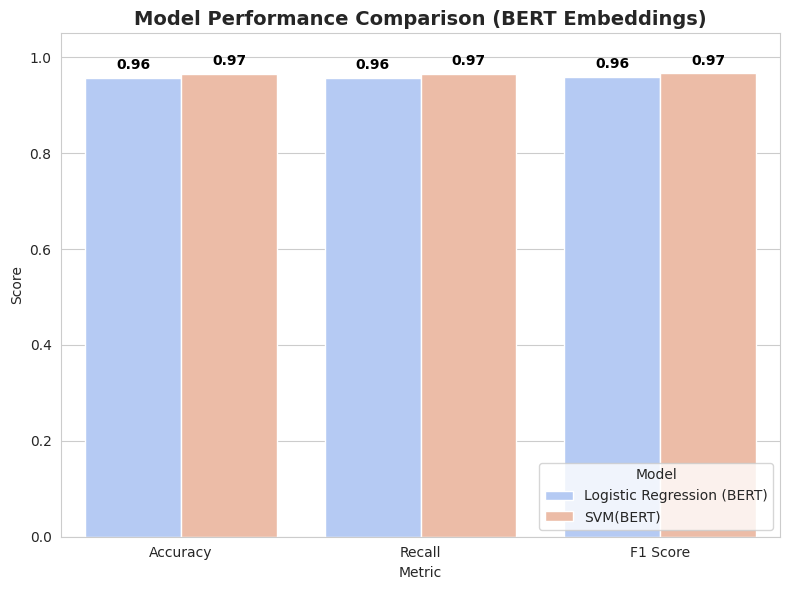

In [23]:
#============== Model Comparision ===================

model_names = ['Logistic Regression', 'Linear SVC']
acc_lr = accuracy_score(y_test, logistic_regression__pred)
rec_lr = recall_score(y_test, logistic_regression__pred, average='weighted')
f1_lr = f1_score(y_test, logistic_regression__pred, average='weighted')

rec_svm = recall_score(y_test, svm_pred, average='weighted')
f1_svm = f1_score(y_test, svm_pred, average='weighted')

metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression (BERT)', 'SVM(BERT)'],
    'Accuracy': [acc_lr, svm_acc],
    'Recall': [rec_lr, rec_svm],
    'F1 Score': [f1_lr, f1_svm]
})

metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='coolwarm')

plt.title("Model Performance Comparison (BERT Embeddings)", fontsize=14, fontweight='bold')
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title='Model', loc='lower right')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black', xytext=(0, 4),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

In [24]:
#=======================Saving the best model============================
f1_lr = f1_score(y_test, logistic_regression__pred, average="macro")
f1_svm = f1_score(y_test, svm_pred, average="macro")

best_model = svm_model if f1_svm > f1_lr else logistic_regression_model
best_name = "Linear SVC" if f1_svm > f1_lr else "Logistic Regression"

joblib.dump(best_model, "bert_sentiment_model.pkl")

['bert_sentiment_model.pkl']

In [25]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

# ======================== Prediction Function ==================

def predict_sentiment(text):
    clean = clean_text(text)
    raw_bert_embedding = get_bert_embedding(clean)

    # Apply PCA transformation to the raw BERT embedding
    bert_embedding_reduced = pca.transform(raw_bert_embedding.reshape(1, -1))

    features = [
        len(clean),
        len(clean.split()),
        clean.count("!"),
        clean.count("?"),
        sum(1 for w in positive_words if w in clean),
        sum(1 for w in negative_words if w in clean)
    ]

    # Combine the PCA-reduced BERT embedding with the simple features
    # Ensure features is also a 2D array (1, N) to match bert_embedding_reduced (1, 100)
    input_vector = np.hstack([bert_embedding_reduced, np.array(features).reshape(1, -1)])

    prediction = best_model.predict(input_vector)[0]

    if hasattr(best_model, 'predict_proba'):
        probability = best_model.predict_proba(input_vector)[0]
    else:
        decision_scores = best_model.decision_function(input_vector)[0]
        probability = softmax(decision_scores)

    return prediction, probability

In [26]:
# ==================== REAL-TIME SENTIMENT ANALYSIS ====================

print("\n" + "=" * 60)
print("REAL-TIME SENTIMENT ANALYSIS SYSTEM (BERT)")
print("=" * 60)

model = best_model
live_df = pd.DataFrame(columns=["review", "sentiment"])

print("\n===== REAL-TIME SENTIMENT ANALYSIS SYSTEM =====")
print("Type reviews one by one.")
print("Type 'show chart' to update dashboard.")
print("Type 'exit' to stop.\n")

while True:
    review = input("Enter review: ")

    if review.lower() == "exit":
        print("System stopped.")
        break

    if review.lower() == "show chart":
        if len(live_df) == 0:
            print("No reviews yet.\n")
            continue

 #=============Sentiment Count Bar Chart=================
        plt.figure(figsize=(6, 4))
        sns.countplot(x="sentiment", data=live_df, palette="viridis")
        plt.title("Real-Time Sentiment Count (BERT)")
        plt.xlabel("Sentiment")
        plt.ylabel("Count")

        ax = plt.gca()
        for p in ax.patches:
            ax.annotate(str(int(p.get_height())),
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', fontsize=10)
        plt.show()

  #===========Trending Line Chart===========================
        plt.figure(figsize=(6, 4))
        live_df["index"] = range(1, len(live_df)+1)
        sns.lineplot(x="index", y="sentiment", data=live_df, marker="o", linewidth=2)
        plt.title("Real-Time Sentiment Trend (BERT)")
        plt.xlabel("Review Number")
        plt.ylabel("Sentiment")
        plt.show()

 #=============Last 10 reviews=============================
        print("\n===== LAST 10 LIVE REVIEWS =====")
        print(live_df.tail(10))
        print("\n")

 #============Alert system=============================
        neg_count = (live_df["sentiment"] == "negative").sum()
        if neg_count >= 3:
            print(" WARNING: NEGATIVE REVIEWS ARE SPIKING!")
            print(f"Negative Count: {neg_count}\n")
        else:
            print(" No negative spikes detected.\n")

        continue

    #===============Predict sentiment======================
    sentiment, prob = predict_sentiment(review)
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: {max(prob):.2%}\n")

    #================Store in live DF=====================
    live_df.loc[len(live_df)] = [review, sentiment]


REAL-TIME SENTIMENT ANALYSIS SYSTEM (BERT)

===== REAL-TIME SENTIMENT ANALYSIS SYSTEM =====
Type reviews one by one.
Type 'show chart' to update dashboard.
Type 'exit' to stop.

Enter review: FOOD IS WORST
Predicted Sentiment: negative
Confidence: 97.08%

Enter review: EXIT
System stopped.
